In [ ]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import tensorflow as tf
import ruptures as rpt

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)



In [ ]:
X_zygo_sub = subject_df["Var_Zygo"].to_numpy() #- np.mean(features_all[["Var_Zygo"]])


In [ ]:
for epoch in range(60):
    X_zygo_sub = subject_df["Corr"].to_numpy() #- np.mean(features_all[["Var_Zygo"]])
    n_bkp = subject_df["Num_Contractions_Corr"].to_numpy()

    signal = X_zygo_sub[epoch]

    energy = signal ** 2  # or use rolling RMS (see below)
    threshold = np.percentile(energy, 85)           # suppress noise floor
    energy_clean = np.where(energy > threshold, energy, 0).reshape(-1, 1)

     
    # Reshape for ruptures (needs 2D)
    energy_2d = energy_clean.reshape(-1, 1)

    # --- Detect 8 change points (start+end for 4 contractions) ---
    model = rpt.Dynp(model="l2",min_size=50).fit(energy_2d)

    #model = rpt.Pelt(model="l2", min_size=100, jump=5).fit(energy_2d)
    breakpoints = model.predict(n_bkps=n_bkp[epoch]*2)

    #model = rpt.Pelt(model="l2", min_size=100, jump=3).fit(energy_2d)
    #breakpoints = model.predict(pen=np.log(len(energy)) * np.var(energy))

    #breakpoints = model.predict(pen=200)

    # --- Visualize ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    # Top: original raw signal
    ax2.plot(subject_df["Corr"].to_numpy()[epoch])
    ax2.set_title("Raw EMG Signal")
    ax2.set_ylabel("Amplitude")

    # Right: energy + change points manually
    ax1.plot(energy_2d)
    for bp in breakpoints[:-1]:  # exclude last point (end of signal)
        ax2.axvline(bp, color='r', linewidth=1.5)
        ax1.axvline(bp, color='r', linewidth=1.5)
    ax1.set_title(f"Epoch {epoch+1} EMG Change Point Detection, contractions={n_bkp[epoch]*2}, breakpoints detected= {len(breakpoints)}")
    ax1.set_ylim(0, 300000)
    ax1.set_ylabel("Energy")
    ax1.set_xlabel("Samples")

    plt.tight_layout()
    plt.show()

    plt.tight_layout()
    plt.show()

In [86]:
def cusum_variance_onset(signal, window_size=50, k=0.5, h=5.0):
    """
    k : slack parameter (sensitivity)
    h : decision threshold (larger = fewer false alarms)
    """
    rolling_var = np.array([
        np.var(signal[max(0, i - window_size):i])
        for i in range(1, len(signal) + 1)
    ])
    
    # Normalize by baseline
    baseline_mean = np.mean(rolling_var[:len(signal) // 10])
    baseline_std  = np.std(rolling_var[:len(signal) // 10])
    z = (rolling_var - baseline_mean) / (baseline_std + 1e-9)
    
    cusum = np.zeros(len(z))
    onsets = []
    for i in range(1, len(z)):
        cusum[i] = max(0, cusum[i-1] + z[i] - k)
        if cusum[i] > h:
            onsets.append(i)
            cusum[i] = 0  # reset after detection
    
    return onsets, rolling_var, cusum

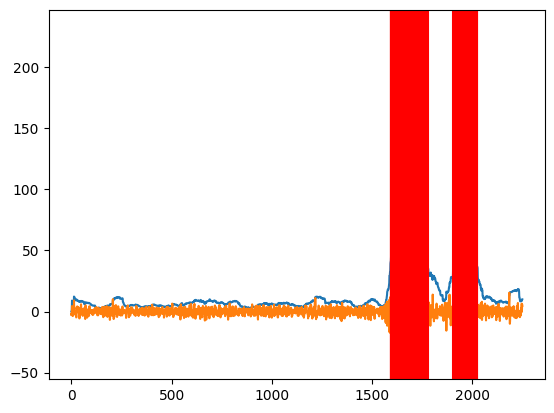

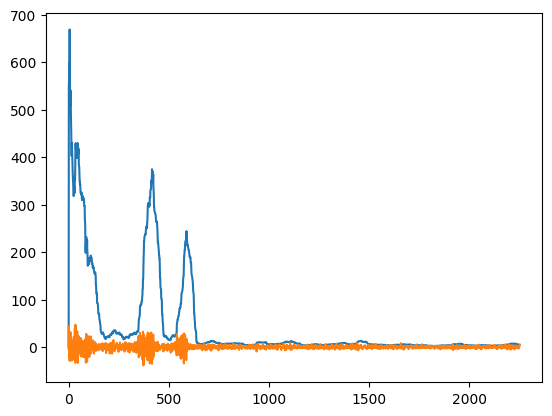

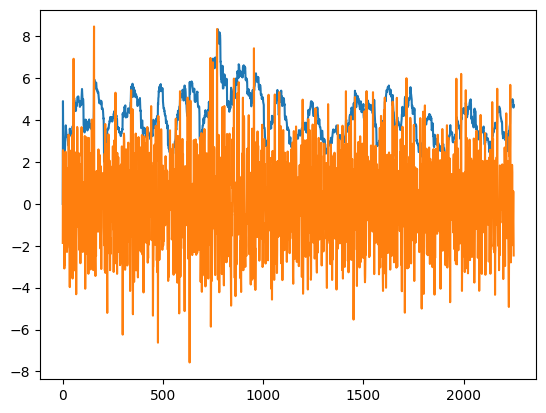

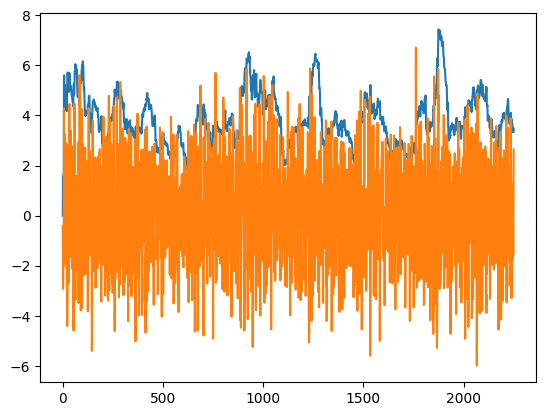

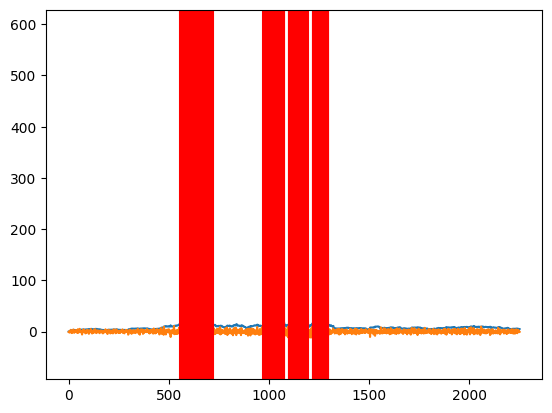

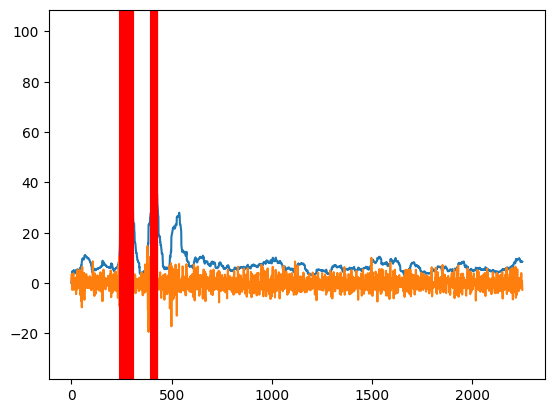

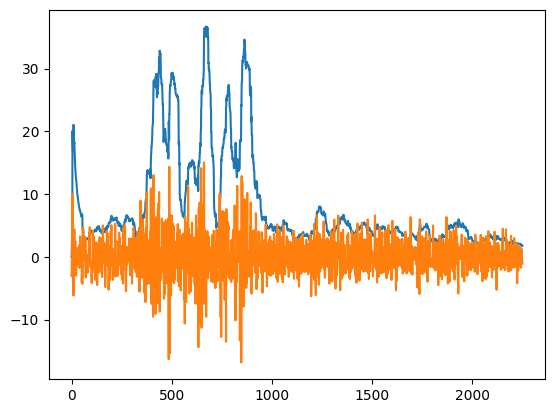

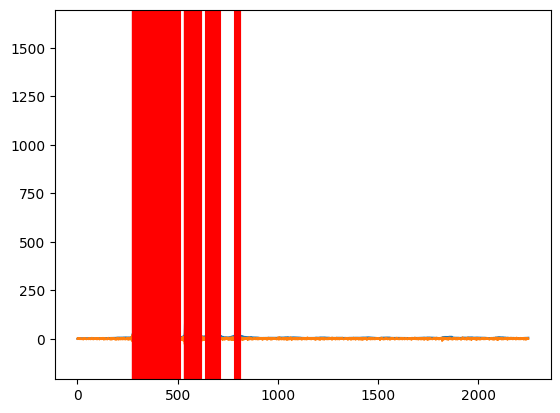

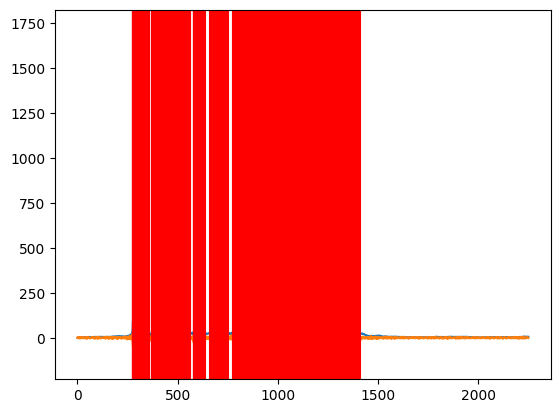

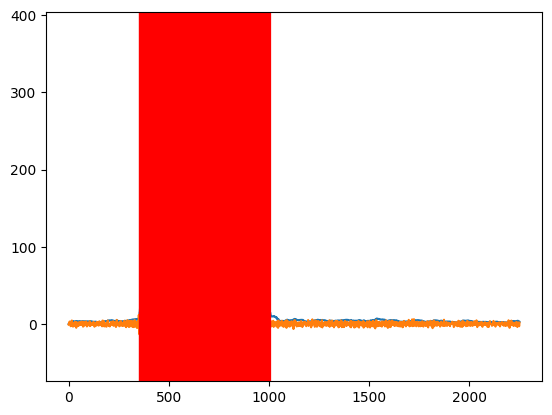

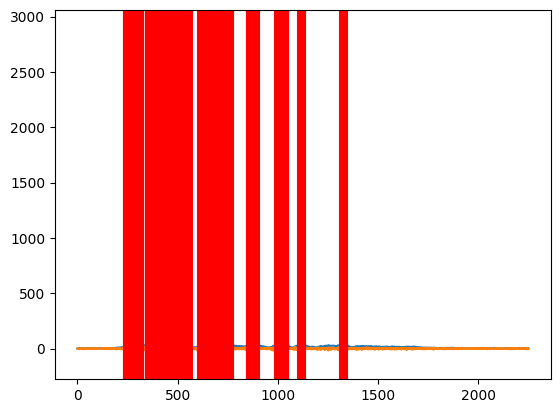

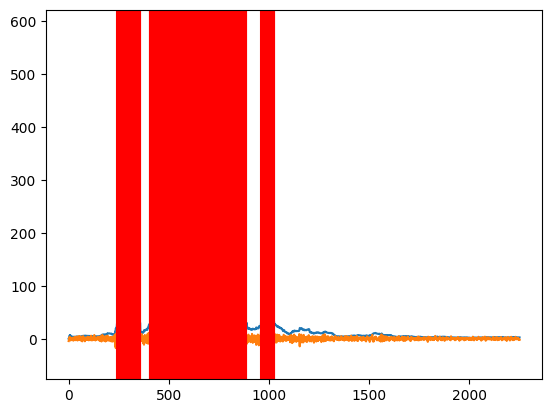

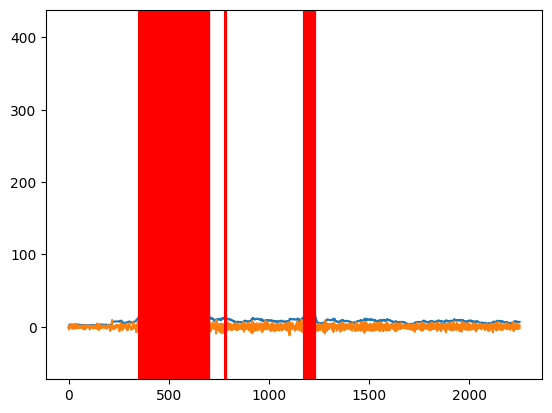

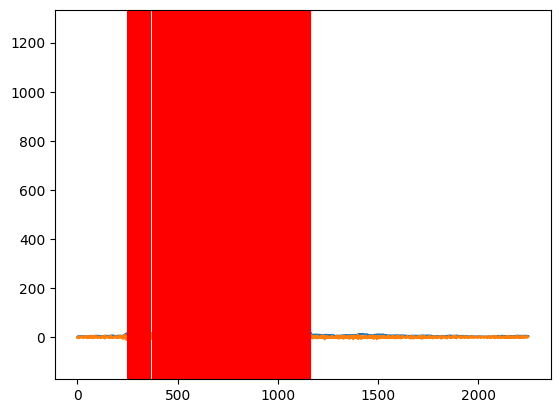

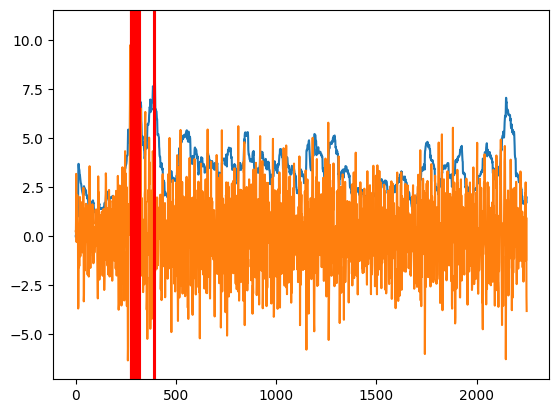

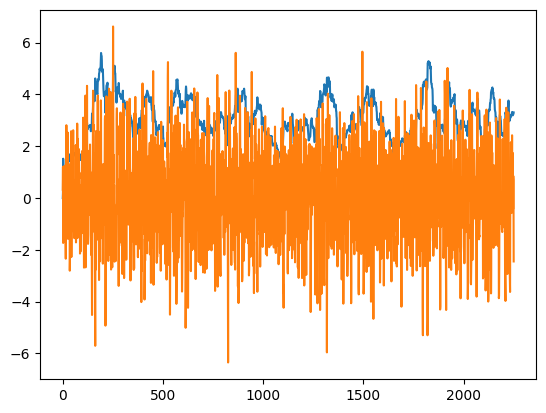

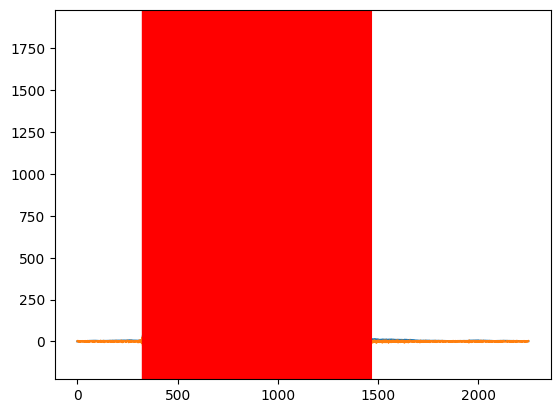

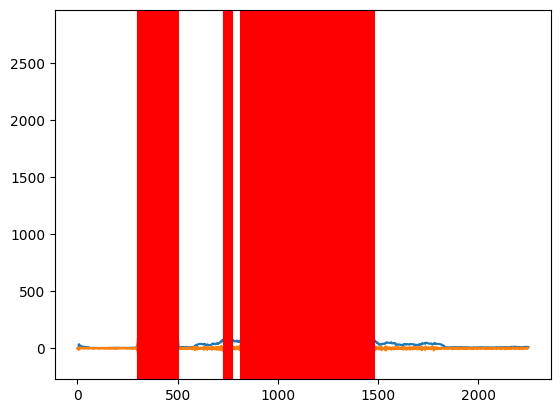

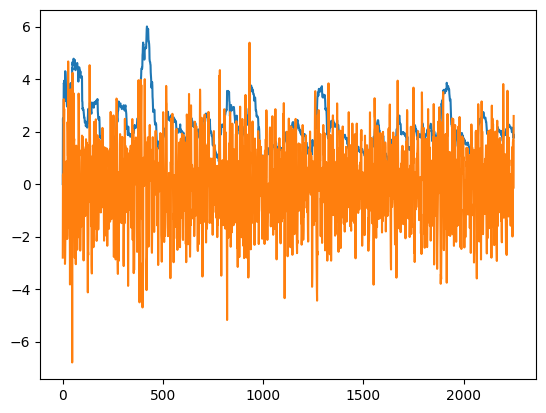

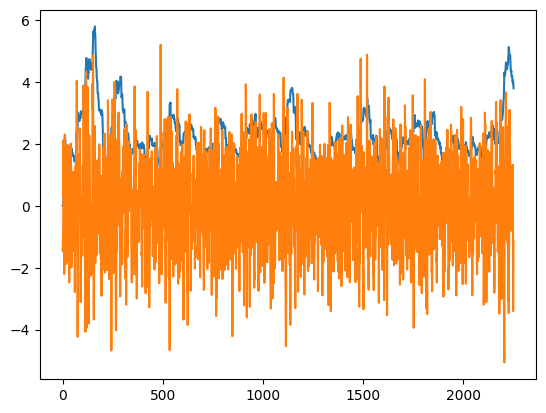

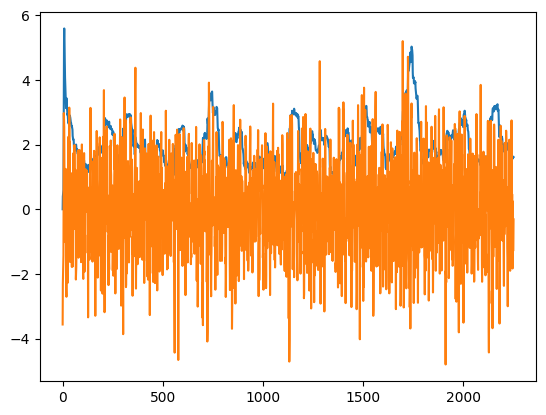

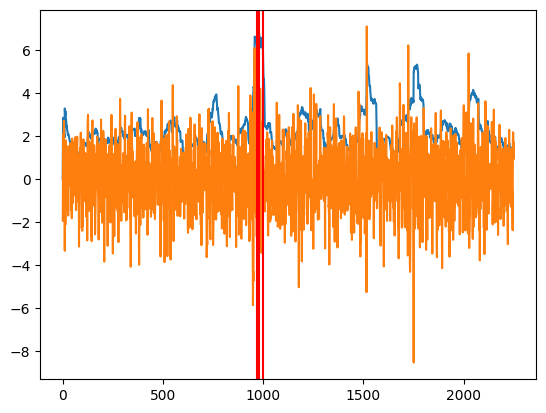

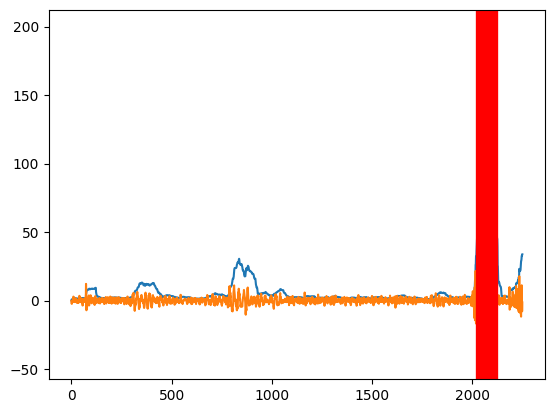

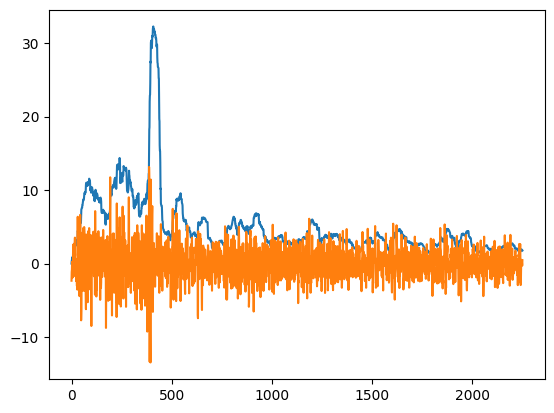

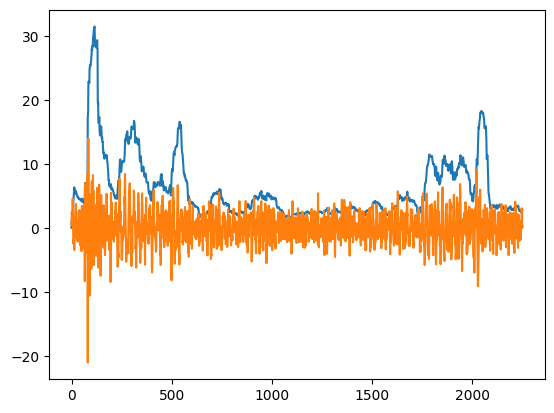

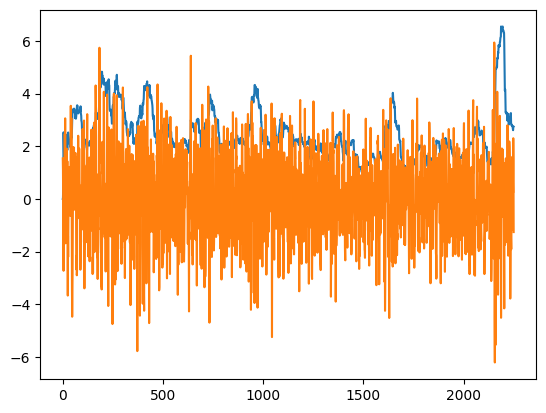

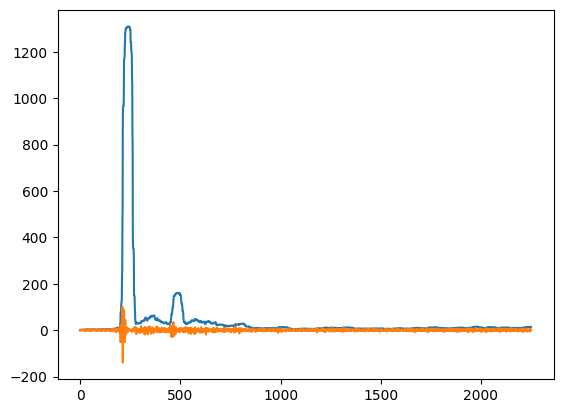

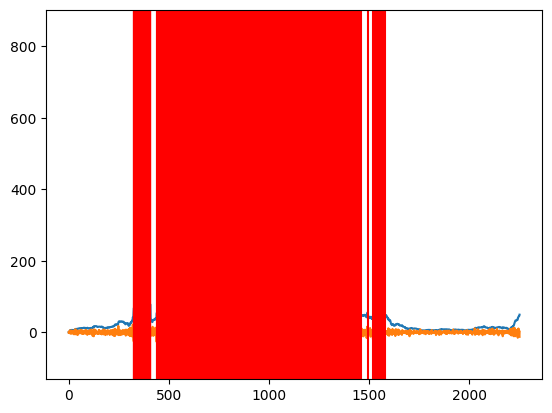

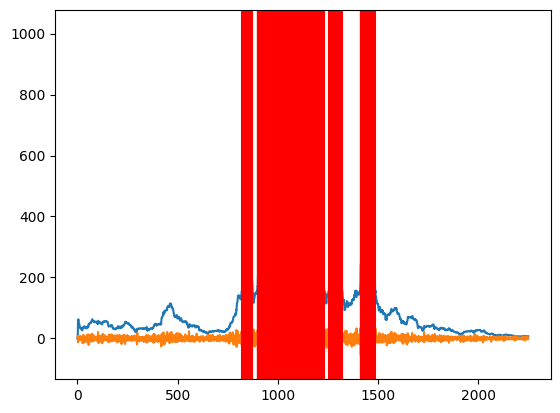

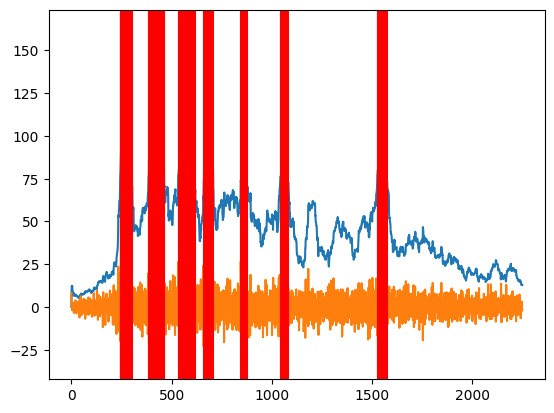

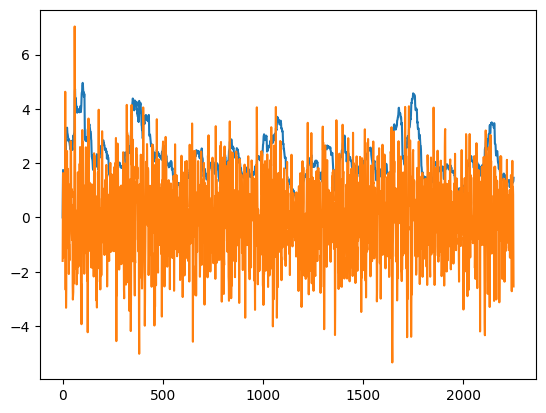

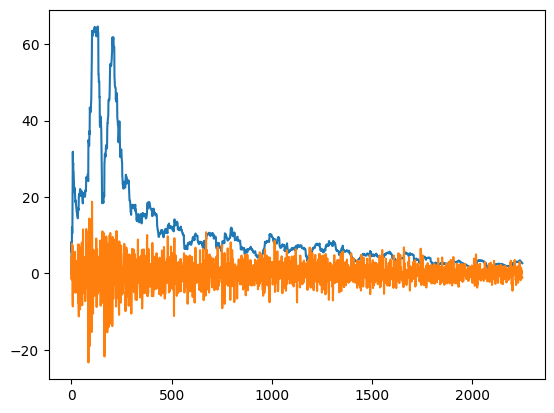

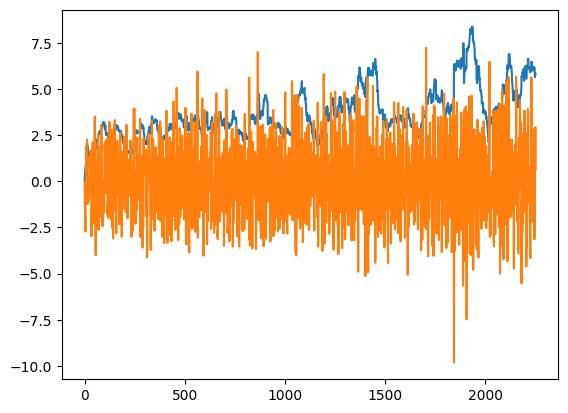

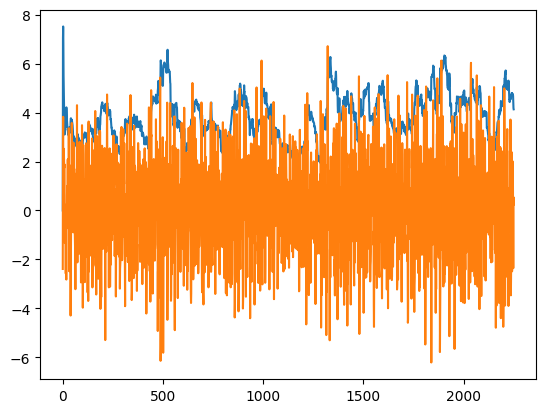

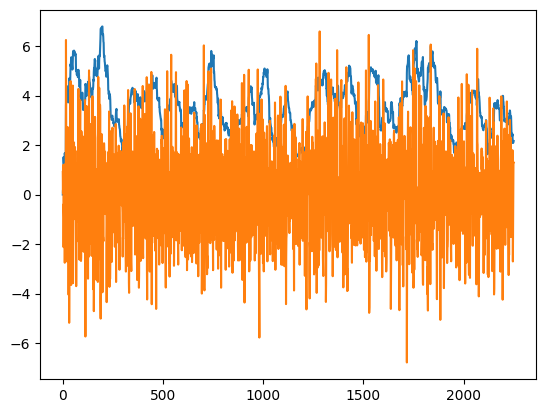

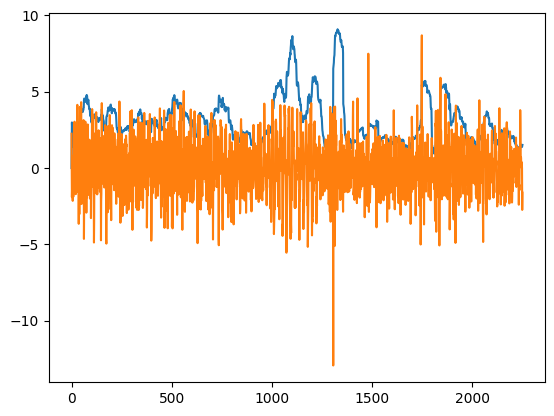

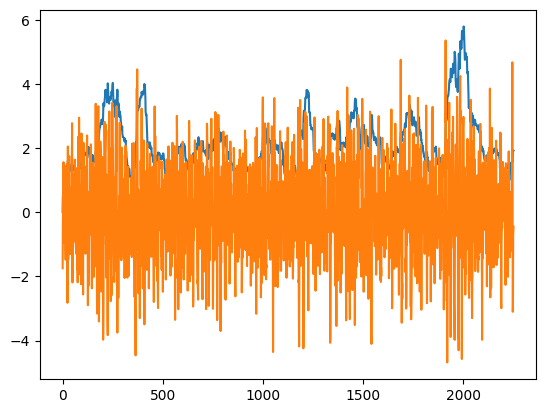

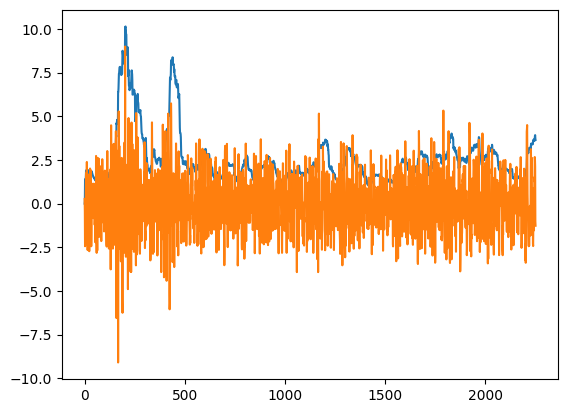

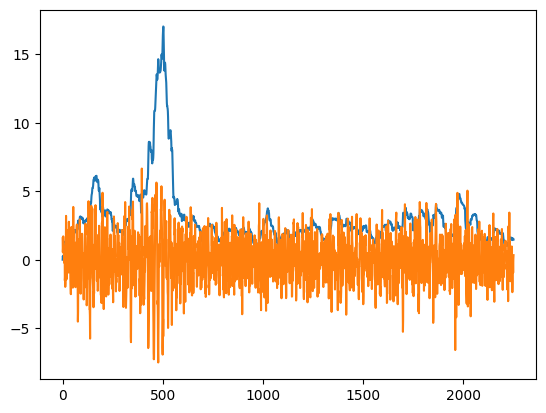

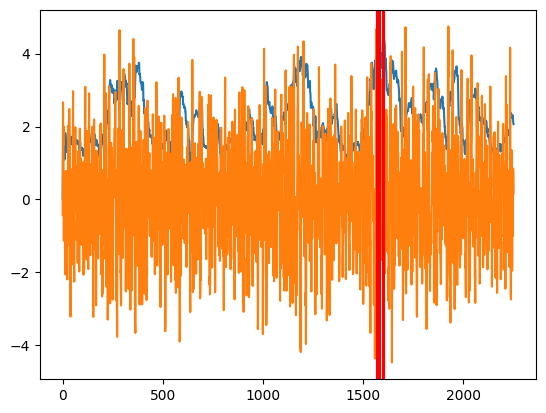

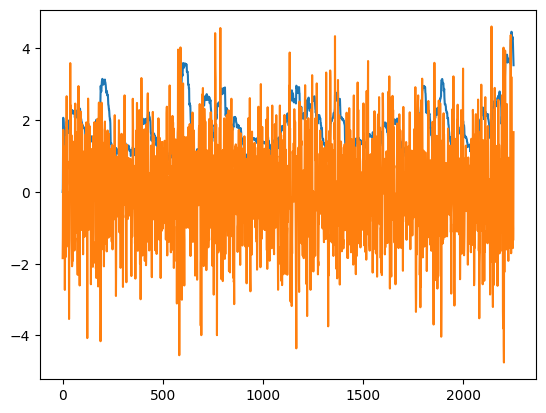

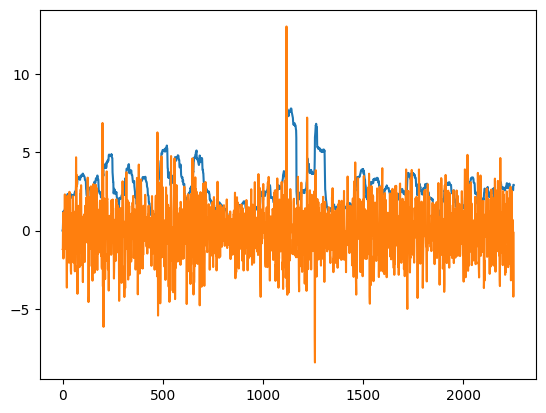

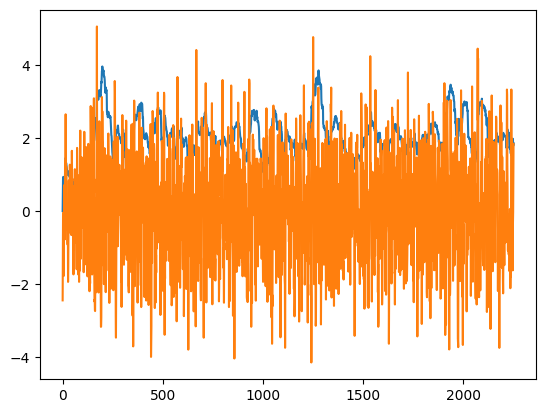

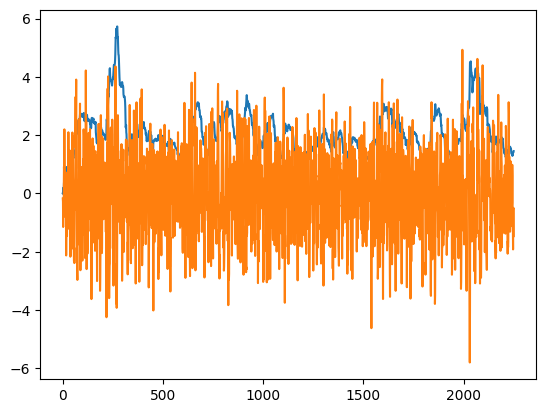

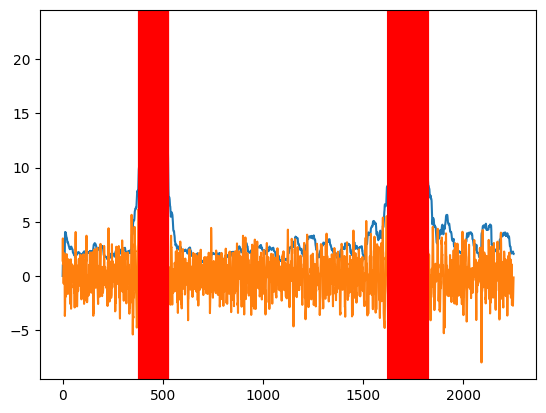

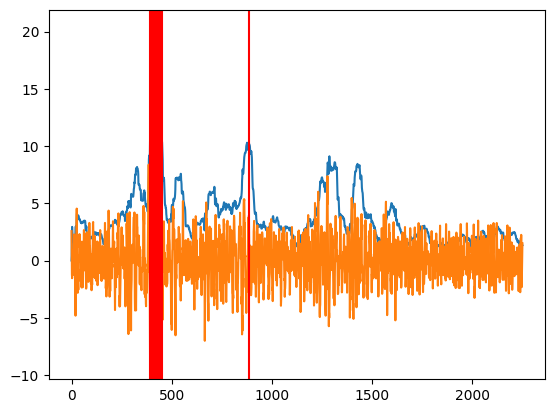

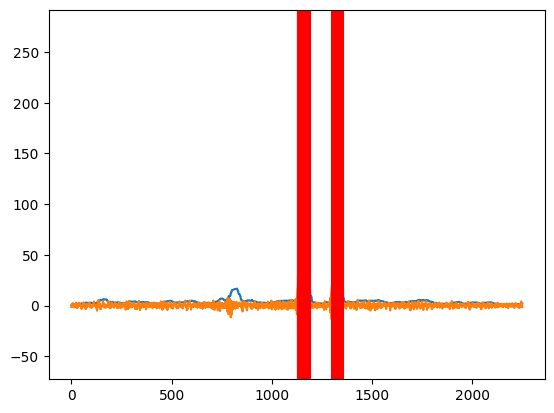

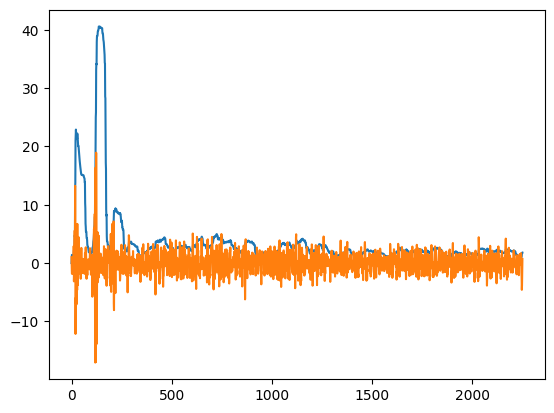

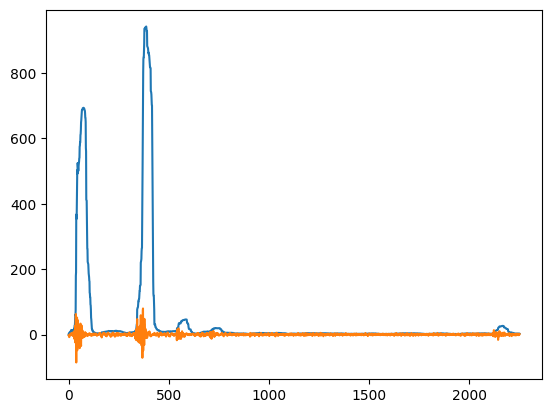

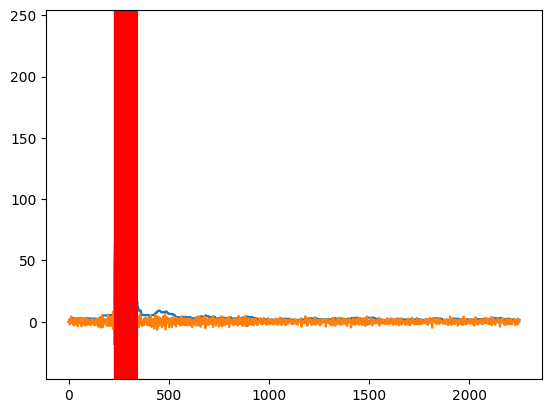

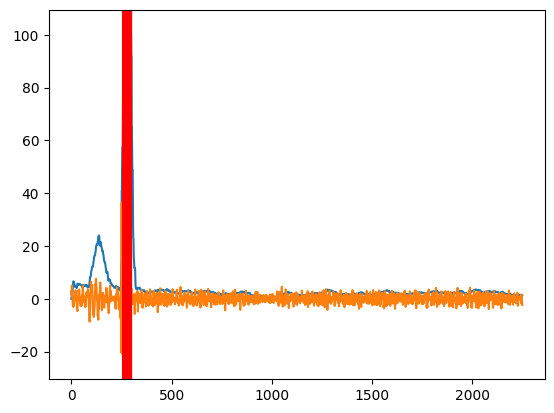

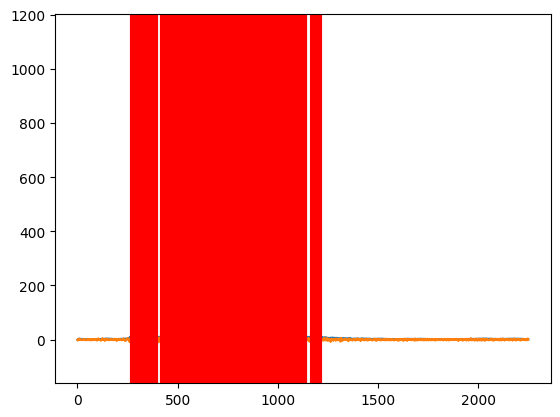

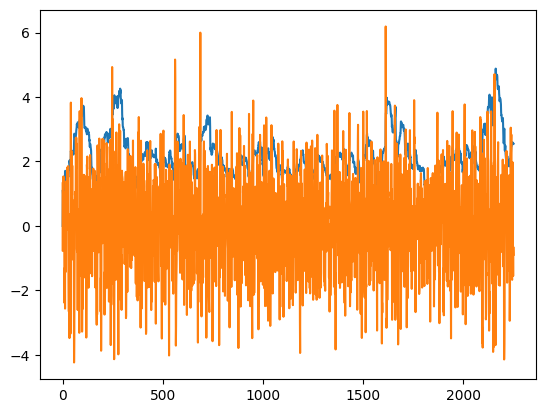

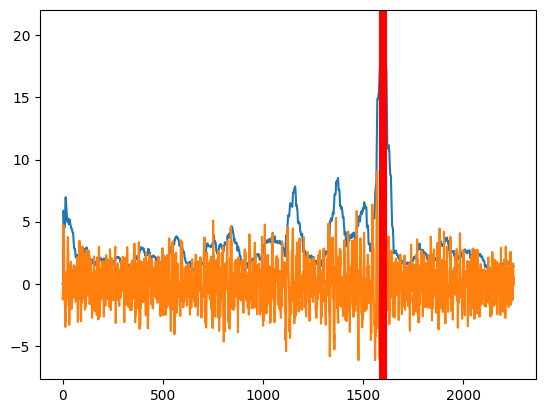

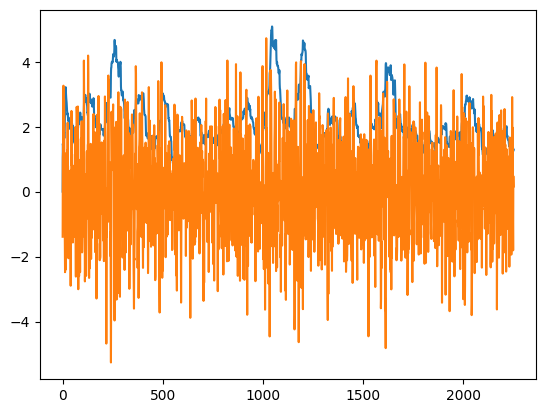

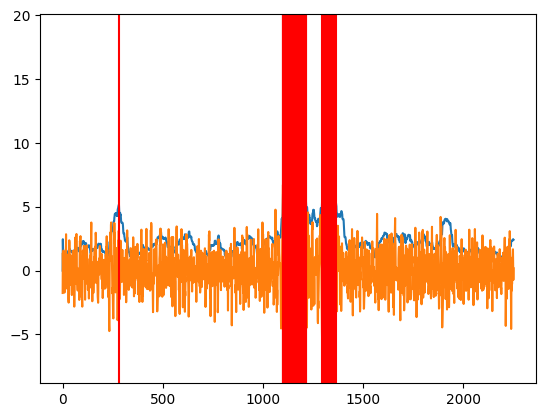

KeyboardInterrupt: 

In [92]:
for epoch in range(60):
    X_zygo_sub = subject_df["Corr"].to_numpy() #- np.mean(features_all[["Var_Zygo"]])
    onsets, rolling_var, cusum = cusum_variance_onset(X_zygo_sub[epoch], window_size=50, k=10, h=5.0)

    plt.plot(rolling_var)
    plt.plot(X_zygo_sub[epoch])
    for on in onsets:
        plt.axvline(on,color='r')
    plt.show()

In [ ]:
features_all = pd.read_pickle("training_features_18042026.pkl")
features_all_temp = features_all
features_all = features_all[~((features_all["Subject"] == "RL03JG") & (features_all["Nap Number"] == 5))] # presentation for this subject is 0 ? somethign weird 

labels = pd.read_pickle("segments.pkl")

print("==========SANITY CHECK==========")
print("Nap IDs align? ", (labels["Nap_ID"].values == features_all["Nap Number"].values).all())
print("Subject rows align? ", (labels["Subject"].values == features_all["Subject"].values).all())
# concatenate dfs
features_all = features_all.reset_index(drop=True)
labels = labels.drop(columns=["Subject"])
labels = labels.reset_index(drop=True)

features_all = pd.concat([features_all, labels], axis=1)  

In [ ]:
subject_plt = "RL09PC"
nap_plt = "02"
subject_df = features_all.loc[(features_all["Subject"] == subject_plt) & (features_all["Nap Number"] == int(nap_plt))] # extract subj info

In [ ]:
X_zygo_sub = subject_df["Var_Zygo"].to_numpy() #- np.mean(features_all[["Var_Zygo"]])
X_corr_sub = subject_df["Var_Corr"].to_numpy() #- np.mean(features_all[["Var_Corr"]] )

y_zygo_sub = subject_df["Contraction Zygo"].to_numpy()
y_corr_sub = subject_df["Contraction Corr"].to_numpy()


In [ ]:

X_zygo = features_all["Var_Zygo"].to_numpy() #- np.mean(features_all[["Var_Zygo"]])
X_corr = features_all["Var_Corr"].to_numpy() #- np.mean(features_all[["Var_Corr"]] )

y_zygo = features_all["Contraction Zygo"].to_numpy()
y_corr = features_all["Contraction Corr"].to_numpy()

subjects = features_all["Subjects"].to_numpy()

all_var_signals = np.concatenate((X_zygo, X_corr), axis=0)
all_labels = np.concatenate((y_zygo, y_corr), axis=0)      
subjects_all = np.concatenate((subjects, subjects), axis=0)  

In [ ]:
import pandas as pd
feature_names = ['variance', 'mean_abs_d1', 'range', 'pct90', 'mean']
df = pd.DataFrame(X_train, columns=feature_names)
df['label'] = y_train
print(df.groupby('label').mean())  # do features actually differ between classes?

### Old code

In [ ]:
epoch = 20 
smooth_window = 2251 
baseline_pct = 30 
var = Zygo_var[epoch] 

baseline = np.percentile(var, baseline_pct)
norm_var = var / baseline 

smoothed = np.convolve(var, np.ones(smooth_window)/smooth_window, mode='same')
d1 = np.diff(smoothed)
d2 = np.diff(d1)

baseline_accel = np.percentile(np.abs(d2[:len(d2)//4]), 95)
accel_threshold = 10 * baseline_accel  # 5× baseline acceleration
refractory=100

onsets = []
last_onset = -refractory
in_contraction = False

for i in range(len(d2)):
    if not in_contraction and d2[i] > accel_threshold:
        onsets.append(i)
        in_contraction = True
    elif in_contraction and d2[i] < 0:
        # acceleration has reversed — contraction is underway, reset
        in_contraction = False
    
